In [15]:
from utils_gene import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Graphe initial : Nodes : 362, Edges : 1988
Variance cible (SBM) : 0.00952425
------------------------------
 Alpha trouvé : 0.5772 pour 1988.0 liens visés.
Step 01 | Sigma testé: 19.1014 | Var: 0.00802236 | Δ: 1.50e-03
 Alpha trouvé : 1.6353 pour 1988.0 liens visés.
Step 02 | Sigma testé: 30.9036 | Var: 0.01177799 | Δ: 2.25e-03
 Alpha trouvé : -0.2275 pour 1988.0 liens visés.
Step 03 | Sigma testé: 11.8072 | Var: 0.00526745 | Δ: 4.26e-03
 Alpha trouvé : 1.0446 pour 1988.0 liens visés.
Step 04 | Sigma testé: 24.0563 | Var: 0.00970444 | Δ: 1.80e-04
 Alpha trouvé : 1.0225 pour 1988.0 liens visés.
Step 05 | Sigma testé: 23.8118 | Var: 0.00962499 | Δ: 1.01e-04
 Alpha trouvé : 0.9974 pour 1988.0 liens visés.
Step 06 | Sigma testé: 23.5358 | Var: 0.00953484 | Δ: 1.06e-05
 Alpha trouvé : 0.9943 pour 1988.0 liens visés.
Step 07 | Sigma testé: 23.5016 | Var: 0.00952362 | Δ: 6.24e-07
 Alpha trouvé : 0.9944 pour 1988.0 liens visés.
Step 08 | Sigma testé: 23.5034 | Var: 0.00952422 | Δ: 2.91e-08
 Al

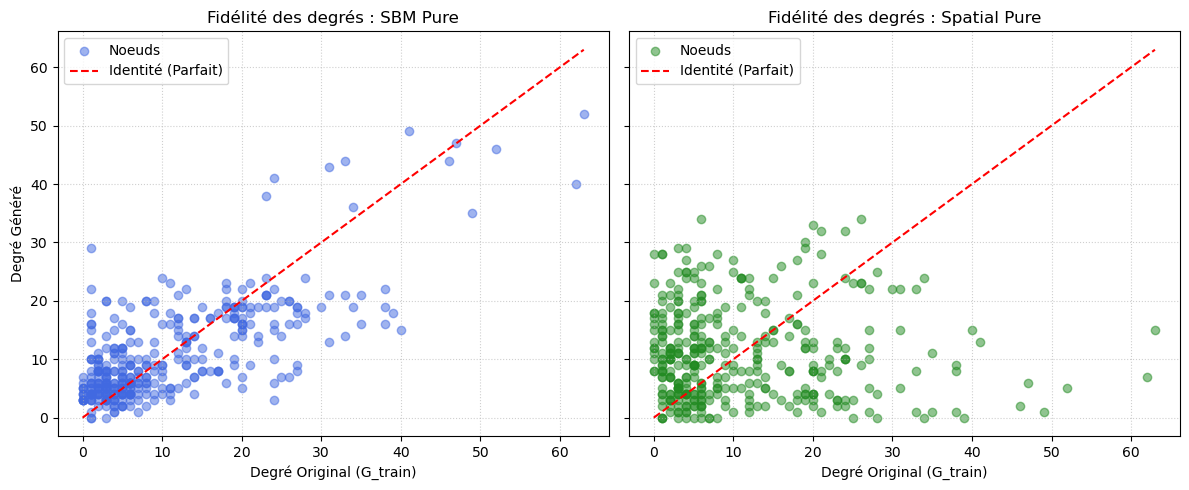

Erreur Moyenne Absolue (MAE) SBM     : 5.28
Erreur Moyenne Absolue (MAE) Spatial : 10.24
Proba moyenne pour les arêtes réelles : 0.340707
Proba min pour une arête réelle : 0.000308621585
Nombre d'arêtes 'impossibles' selon le modèle : 0
Proba moyenne pour les arêtes réelles : 0.342379
Proba min pour une arête réelle : 0.000714285714
Nombre d'arêtes 'impossibles' selon le modèle : 0


In [16]:
G_name = "reel_facebook_friends_w_attributes"
path = f"../../graph_library/{G_name}"
G = joblib.load(path)
print(f"Graphe initial : Nodes : {G.number_of_nodes()}, Edges : {G.number_of_edges()}")

e_rs, k, commus = get_real_graph_properties_sbm_V2(G)
P_sbm = get_probs_sbm_non_DC(e_rs, commus)

degrees, position = get_real_graph_properties_pos_V2(G)
sigma_opt, P_spatial_calibrated = match_spatial_to_sbm_variance(P_sbm, degrees, position, DC=False)
P_spatial = get_probs_spatial_non_DC(position, n_liens_target= G.number_of_edges(), sigma = sigma_opt)
#P_spatial = get_probs_spatial_sinkhorn(degrees, position, sigma=0.282)

g_sbm = generate_graph_from_probs(P_sbm)
g_spatial = generate_graph_from_probs(P_spatial)
g_spatial_nx = convert_to_nx_with_metadata(g_spatial, position, commus)
nu = g_spatial_nx.nodes[0]
print(f"DEBUG: Attr cherché: | Présents dans nu: {list(nu.keys())}")

print(f"SBM VS spatial = {g_sbm.num_edges()} VS {g_spatial.num_edges()}")

entropy_sbm = get_entropy_from_p(P_sbm)
log_likelyhood_sbm = get_log_likelihood(g_sbm, P_sbm)
entropy_spatial = get_entropy_from_p(P_spatial)
log_likelyhood_spatial = get_log_likelihood(g_spatial, P_spatial)
var_sbm = get_variance_from_P(P_sbm)
var_spatial = get_variance_from_P(P_spatial)

print(f" Entropy VS Log_likelyhood SBM : {entropy_sbm} / {log_likelyhood_sbm}")
print(f" Entropy VS Log_likelyhood Spatial : {entropy_spatial} / {log_likelyhood_spatial}")
print(f" Variance SBM VS Spatial : {var_sbm} / {var_spatial}")

plot_degree_correlation(k, g_sbm, g_spatial)
#visualize_generation_diagnostics_v2(P_sbm, P_spatial, k, e_rs, b)

analyze_errors(g_spatial, P_spatial)
analyze_errors(g_sbm, P_sbm)

In [17]:
Hybrid_ratios_list = np.arange(0, 1.25, 0.25)

generate_graph_benchmarks(Hybrid_ratios_list, P_sbm, P_spatial, position, commus, name="artificial_graph_sbmv4")


Pour ratio_sbm = 0.0

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv4_0_00_pos_1_00.graphml
ID SBM : 8 (Type: <class 'int'>)
Position : [0.3261446, 0.9788656, 0.8554306, 0.10845247]

Pour ratio_sbm = 0.25

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv4_0_25_pos_0_75.graphml
ID SBM : 8 (Type: <class 'int'>)
Position : [0.3261446, 0.9788656, 0.8554306, 0.10845247]

Pour ratio_sbm = 0.5

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv4_0_50_pos_0_50.graphml
ID SBM : 8 (Type: <class 'int'>)
Position : [0.3261446, 0.9788656, 0.8554306, 0.10845247]

Pour ratio_sbm = 0.75

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv4_0_75_pos_0_25.graphml
ID SBM : 8 (Type: <class 'int'>)
Position : [0.3261446, 0.9788656, 0.8554306, 0.10845247]

Pour ratio_sbm = 1.0

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv4_1_00_pos_0_00.graphml
ID SBM : 8 (Type: <class 'in